In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pickle
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Bank Customer Churn Prediction.csv", delimiter=",")

In [3]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


(array([7963., 2037.]),
 array([0. , 0.5, 1. ]),
 <BarContainer object of 2 artists>)

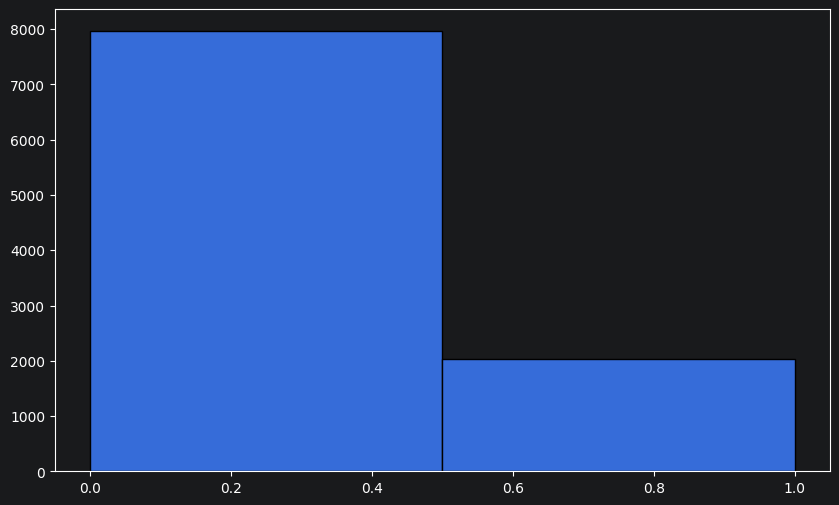

In [4]:
plt.figure(figsize=(10, 6))
plt.hist(df['churn'], bins=2, edgecolor='black')

In [5]:
# preprocessing the data

df = df.drop(['customer_id'], axis=1)

In [6]:
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
label_encoder_gender = LabelEncoder()
df['gender'] = label_encoder_gender.fit_transform(df['gender'])

In [8]:
df

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


In [9]:
##One hote encoding for geograpghy column

from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(sparse_output=False, drop='first')
geography_encoded = one_hot_encoder.fit_transform(df[['country']])

In [10]:
geography_encoded

array([[0., 0.],
       [0., 1.],
       [0., 0.],
       ...,
       [0., 0.],
       [1., 0.],
       [0., 0.]], shape=(10000, 2))

In [11]:
one_hot_encoder.get_feature_names_out(['country'])

array(['country_Germany', 'country_Spain'], dtype=object)

In [12]:
geo_encoder_df = pd.DataFrame(geography_encoded, columns=one_hot_encoder.get_feature_names_out(['country']))

In [13]:
geo_encoder_df

,country_Germany,country_Spain
0,0.0,0.0
1,0.0,1.0
2,0.0,0.0
3,0.0,0.0
4,0.0,1.0
...,...,...
9995,0.0,0.0
9996,0.0,0.0
9997,0.0,0.0
9998,1.0,0.0


In [14]:
## combining the one hot encoded columns with the original dataframe



df = pd.concat([df.drop('country',axis=1), geo_encoder_df], axis=1)

In [15]:
df

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,0.0,0.0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,0.0,0.0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,0.0,0.0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,1.0,0.0


In [16]:
 ## save trhe encoders and scaler for future use
 
 
with open('label_encoder_gender.pkl', 'wb') as f:
     pickle.dump(label_encoder_gender, f)
     
     
with open('one_hot_encoder.pkl', 'wb') as f:
    pickle.dump(one_hot_encoder, f)
 
 

In [17]:
# splitting dependent and dependent variables

X = df.drop('churn', axis=1)
y = df['churn']


In [18]:
## Trai test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#scale down features

In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
X_train

array([[ 0.35649971,  0.91324755, -0.6557859 , ...,  1.36766974,
        -0.57946723, -0.57638802],
       [-0.20389777,  0.91324755,  0.29493847, ...,  1.6612541 ,
         1.72572313, -0.57638802],
       [-0.96147213,  0.91324755, -1.41636539, ..., -0.25280688,
        -0.57946723,  1.73494238],
       ...,
       [ 0.86500853, -1.09499335, -0.08535128, ..., -0.1427649 ,
        -0.57946723, -0.57638802],
       [ 0.15932282,  0.91324755,  0.3900109 , ..., -0.05082558,
        -0.57946723, -0.57638802],
       [ 0.47065475,  0.91324755,  1.15059039, ..., -0.81456811,
         1.72572313, -0.57638802]], shape=(8000, 11))

In [21]:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

#### ANN Implementation

In [22]:
import tensorflow as tf
import keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard
import datetime

In [23]:
X_train.shape[1]

11

In [25]:
model = Sequential([
    Dense(64,activation='relu', input_shape=(X_train.shape[1],)), #HL1
    Dense(32, activation='relu'), # HL2
    Dense(1, activation='sigmoid') # output layer
    
])

C:\Development\GenAI_Udemy_Krishnaik\ANN_CLASSIFICATION\ANN_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
opt = tf.keras.optimizers.Adam(learning_rate=0.01)
opt

In [28]:
loss = tf.keras.losses.BinaryCrossentropy()

In [29]:
## compile the model

model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [30]:
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [31]:
## Set up early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [33]:
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), callbacks=[early_stopping, tensorboard_callback])

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8374 - loss: 0.3943 - val_accuracy: 0.8550 - val_loss: 0.3533
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8568 - loss: 0.3519 - val_accuracy: 0.8635 - val_loss: 0.3409
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8571 - loss: 0.3444 - val_accuracy: 0.8595 - val_loss: 0.3530
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8591 - loss: 0.3425 - val_accuracy: 0.8635 - val_loss: 0.3426
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8596 - loss: 0.3397 - val_accuracy: 0.8615 - val_loss: 0.3437
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8600 - loss: 0.3352 - val_accuracy: 0.8590 - val_loss: 0.3467
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8612 - loss: 0.3325 - val_accuracy: 0.8595 - val_loss: 0.3379
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8662 - loss: 0.3317 - val_

In [41]:
model.save('churn_model.h5')

In [42]:
## Tensor Board Extensioon

%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [43]:
%tensorboard --logdir logs/fit

In [ ]:
## Load the pickle file
